# General Spherical Harmonics Implementation

This implementation adds the perturbed gravity forces of a central body, such as Earth (or Moon, etc.) given by a non-perfect-spherical body. Similarly to the implementation of the J2 (Ecuatorial Oblateness), the aim of this notebook is to get to know how to use the more general aproach.

Let's start by inicialliting our simulation: 

In [1]:
import rebound
import reboundx
import numpy as np
from math import factorial, sqrt
import matplotlib.pyplot as plt

sim = rebound.Simulation()
sim.units = ('m', 's', 'kg')

sim.integrator = "ias15"
sim.move_to_com()

In [2]:
r_earth     = 6371e3         # m
m_earth     = 5.9736*10**24  # kg
G           = sim.G          # 6.67e-11 N*m**2/Kg**2, Universal Gravitational Constant      
R_eq        = 6378136.3      # m, equatorial radius (EGM96/EGM2008 convention)
omega_earth = 7.292115e-5    # rad/s, Earth sidereal rotation rate
theta0      = 0.0            # body-fixed frame orientation at t=0 (GMST at epoch)


sim.add(m=m_earth, r=r_earth, hash=str("Earth"))

Now we add the perturbated gravity force: 
There are two ways to add the main perturbation:

    1.- By the Hard-Coding Harmonics implemented (J2, J4, J6, J8, J10)



In [3]:
inc = np.deg2rad(45)

r = 7000e3

mu = sim.G * m_earth
v = np.sqrt(mu/r)
sim.add(m=1000.0, x = r, y = 0, z = 0, vx = 0, vy = v*np.cos(inc), vz = v*np.sin(inc), hash='Sat')

# Extracting the orbital elements of the Satellites orbit:
orb0 = sim.particles["Sat"].orbit(primary=sim.particles["Earth"])
e   = orb0.e
a   = orb0.a
inc = orb0.inc      
Omega0 = orb0.Omega

print(f"a = {a:.4e} m,  e = {e:.6f},  inc = {np.degrees(inc):.3f} deg")

a = 7.0000e+06 m,  e = 0.000000,  inc = 45.000 deg


Now we define the hard-coding perturbation, with a slight change. Lookout at the J6 term, which it hasn't got it's true value. The intention is to show that the new implementation of the elements J6, J8 and J10 have an influence over the simulation, though its true value almost doesn't reflect it.

Furthermore, the hard-coding implementation is the same as before with the J2 and J4 elements.

In [4]:
# First implementation: Hard-Coded

rebx = reboundx.Extras(sim)
gh = rebx.load_force("gravitational_harmonics")


# Using the Spherical Harmonics from the Earth: 
J2  =  1.0826e-3
J4  = -1.6196e-6
J6  =  5.4068e-7
J8  = -1.5e-7
J10 =  5.0e-8

sim.particles["Earth"].params["J2"] = J2
sim.particles["Earth"].params["J4"] = J4
sim.particles["Earth"].params["J6"] = 5e-4
sim.particles["Earth"].params["J8"] = J8
sim.particles["Earth"].params["J10"] = J10

sim.particles["Earth"].params["R_eq"] = R_eq 

rebx.add_force(gh)

We can now compare the analytical result of the J2 perturbation: The Nodal Precession, with all the perturbations trying to make a real difference. 

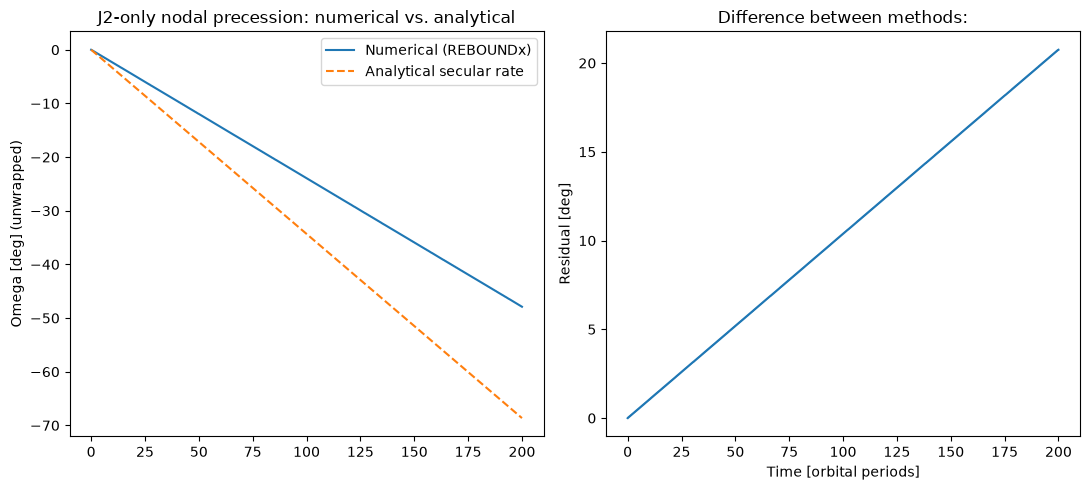

In [5]:
# ---------------------------------------------------------------
# Integrate and record Omega(t)
# ---------------------------------------------------------------

n_mean = np.sqrt(G * m_earth / a**3)   # mean motion
period = 2 * np.pi / n_mean
 
n_orbits = 200          # enough orbits to get a clean secular slope
n_out = 2000
times = np.linspace(0.0, n_orbits * period, n_out)
 
Omega_num = np.zeros(n_out)
for i, t in enumerate(times):
    sim.integrate(t)
    orb = sim.particles["Sat"].orbit(primary=sim.particles["Earth"])
    Omega_num[i] = orb.Omega
 
# Omega decreases steadily (for prograde inclination < 90) and will wrap
# around -pi/pi -- unwrap before fitting a line
Omega_unwrapped = np.unwrap(Omega_num)

# ---------------------------------------------------------------
# Analytical secular rate
# ---------------------------------------------------------------
p = a * (1 - e**2)
Omega_dot_analytic = -1.5 * n_mean * J2 * (R_eq / p)**2 * np.cos(inc)


# ---------------------------------------------------------------
# Numerical secular rate: linear fit to the unwrapped Omega(t)
# ---------------------------------------------------------------
slope, intercept = np.polyfit(times, Omega_unwrapped, 1)
Omega_dot_numeric = slope

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True)
 
axes[0].plot(times / period, np.degrees(Omega_unwrapped), label="Numerical (REBOUNDx)")
axes[0].plot(times / period,
             np.degrees(Omega_unwrapped[0] + Omega_dot_analytic * times),
             "--", label="Analytical secular rate")
axes[0].set_ylabel("Omega [deg] (unwrapped)")
axes[0].legend()
axes[0].set_title("J2-only nodal precession: numerical vs. analytical")
 
residual = Omega_unwrapped - (Omega_unwrapped[0] + Omega_dot_analytic * times)
axes[1].plot(times / period, np.degrees(residual))
axes[1].set_xlabel("Time [orbital periods]")
axes[1].set_ylabel("Residual [deg]")
axes[1].set_title("Difference between methods:")
 
plt.tight_layout()
plt.show()

The results show clearly a perturbation given by the "intruder" (J6), with the purpouse of showing the influence that each of these terms of perturbation have. 

The implementation of the Gravitational Harmonics allows the hard-coding of the Zonal-Harmonics as long as the "general model" doesn't exist. 

    2.- Using the general model, while adding the spherical harmonics that the user needs.

Let's create another simulation with a satellite orbiting the Earth with a Geostationary orbit (the orbit period equals Earth's sidereal rotation period):

In [6]:
sim1 = rebound.Simulation()
sim1.units = ('m', 's', 'kg')

sim1.integrator = "ias15"
sim1.move_to_com()

r_earth     = 6371e3         # m
m_earth     = 5.9736*10**24  # kg
G           = sim1.G          # 6.67e-11 N*m**2/Kg**2, Universal Gravitational Constant      
R_eq        = 6378136.3      # m, equatorial radius (EGM96/EGM2008 convention)
omega_earth = 7.292115e-5    # rad/s, Earth sidereal rotation rate
theta0      = 0.0            # body-fixed frame orientation at t=0 (GMST at epoch)


sim1.add(m=m_earth, r=r_earth, hash=str("Earth"))

In [7]:
r_geo = (G*m_earth / omega_earth**2) ** (1.0 / 3.0)

lon0_deg = 0.0
lon0 = np.radians(lon0_deg)
 
x = r_geo * np.cos(lon0)
y = r_geo * np.sin(lon0)
z = 0.0
 
v_circ = np.sqrt(G*m_earth / r_geo)     # Velocity for circular orbit
vx = -v_circ * np.sin(lon0)
vy = v_circ * np.cos(lon0)
vz = 0.0
 
sim1.add(m=0.0, x=x, y=y, z=z, vx=vx, vy=vy, vz=vz, hash="sat")

Now we define 2 functions which are useful for our implementation of the model:

In [8]:
# Define functions: 


def idx(n, m):
    return n*(n+1)//2 + m


For applying the general model, we need to introduce the arrays C and S to the model, with the constants of the body that is going to recreate such perturbations.

In [9]:
# Second Implementation: General Model

rebx = reboundx.Extras(sim1)
gh = rebx.load_force("gravitational_harmonics")


# Using the Spherical Harmonics from the Earth: 
C22 = 1.574615e-6
S22 = -0.903872e-6

N = 2
size = (N+1)*(N+2)//2

# Normalized coefficients using the 4-pi normalization
C = np.zeros(size, dtype=np.float64)
S = np.zeros(size, dtype=np.float64)
 
C[idx(2,2)] = C22
S[idx(2,2)] = S22


model = reboundx.spherical_harmonics_model(
    C,
    S,
    G*m_earth,
    R_eq,
)

sim1.particles["Earth"].params["spherical_harmonics_model"] = model
sim1.particles["Earth"].params["Omega"] = [0, 0, omega_earth]

rebx.add_force(gh)

We implement the terms C22 and S22 in order to show the libration formed on the GEO satellite with the rotation of the Earth. Due to the Tesseral elements (C22 and S22) and the rotation of the Earth, the satellite oscillates such as a pendulum around the stable equilibrium point. This is better explained by: "Blitzer, L. (1965), **Equilibrium positions and stability of 24-hour satellite orbits**, J. Geophys. Res., 70(16), 3987–3992, doi:10.1029/JZ070i016p03987".

In [10]:
# ---------------------------------------------------------------
# Integrate and track the longitude in the Earth-fixed frame
# ---------------------------------------------------------------
sidereal_day = 2.0 * np.pi / omega_earth
n_periods_libration_estimate = 1200
n_periods = n_periods_libration_estimate * 4
n_out = 10000
times = np.linspace(0.0, n_periods * sidereal_day, n_out)
 
lon_deg = np.zeros(n_out)
for i, t in enumerate(times):
    sim1.integrate(t)
    p = sim1.particles["sat"]
    lambda_inertial = np.arctan2(p.y, p.x)
    theta = theta0 + omega_earth * t
    # wrap into (-180, 180]
    lon_deg[i] = np.degrees((lambda_inertial - theta + np.pi) % (2 * np.pi) - np.pi)

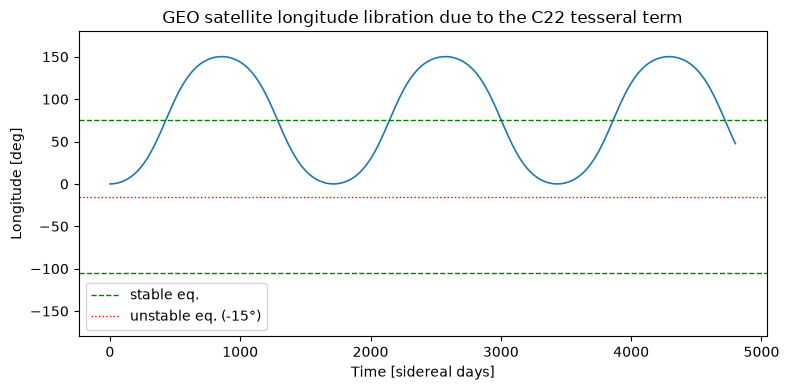

In [11]:
# ---------------------------------------------------------------
# Plot: longitude vs time should show libration around 75 deg E
# ---------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(times / sidereal_day, lon_deg, lw=1.2)
plt.axhline(75.0, color="g", ls="--", lw=1, label="stable eq. ")
plt.axhline(-105.0, color="g", ls="--", lw=1)
plt.axhline(-15.0, color="r", ls=":", lw=1, label="unstable eq. (-15°)")
plt.ylim(-180,180)
plt.xlabel("Time [sidereal days]")
plt.ylabel("Longitude [deg]")
plt.title("GEO satellite longitude libration due to the C22 tesseral term")
plt.legend()
plt.tight_layout()
plt.show()